# Week 1: Bank of America Stock Data — Cleaning and EDA

**Author:** Preyash Gandhi

## Objective
Explore historical stock prices and trading volume, check data quality,
and identify patterns for further financial analysis.

## Dataset
- Source: Kaggle — Bank of America Corp. Stock Data
- Records: 13,329
- Original columns: 8
- Period: 21 February 1973 to 31 December 2025
- Stock ticker: BAC

## Limitation
The dataset's price adjustment method has not been confirmed.
Price summaries are descriptive and should not be interpreted as
total investment returns.

In [25]:
import pandas as pd

df = pd.read_csv("Bank_of_America_historical_data.csv")

df.head()

,Date,Open,High,Low,Close,Volume,ticker,name
0,1973-02-21 00:00:00-05:00,1.507640,1.507640,1.507640,1.507640,99200,BAC,Bank of America Corporation (BAC) Historical Data
1,1973-02-22 00:00:00-05:00,1.512735,1.512735,1.512735,1.512735,47200,BAC,Bank of America Corporation (BAC) Historical Data
2,1973-02-23 00:00:00-05:00,1.507640,1.507640,1.507640,1.507640,133600,BAC,Bank of America Corporation (BAC) Historical Data
3,1973-02-26 00:00:00-05:00,1.507640,1.507640,1.507640,1.507640,24000,BAC,Bank of America Corporation (BAC) Historical Data
4,1973-02-27 00:00:00-05:00,1.507640,1.507640,1.507640,1.507640,41600,BAC,Bank of America Corporation (BAC) Historical Data


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13329 entries, 0 to 13328
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    13329 non-null  str    
 1   Open    13329 non-null  float64
 2   High    13329 non-null  float64
 3   Low     13329 non-null  float64
 4   Close   13329 non-null  float64
 5   Volume  13329 non-null  int64  
 6   ticker  13329 non-null  str    
 7   name    13329 non-null  str    
dtypes: float64(4), int64(1), str(3)
memory usage: 833.2 KB


In [27]:
df["Date"] = pd.to_datetime(df["Date"], utc= True)
df["Date"] = df["Date"].dt.tz_convert("America/New_York")

df[["Date"]].head()



,Date
0,1973-02-21 00:00:00-05:00
1,1973-02-22 00:00:00-05:00
2,1973-02-23 00:00:00-05:00
3,1973-02-26 00:00:00-05:00
4,1973-02-27 00:00:00-05:00


In [28]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate dates:", df["Date"].duplicated().sum())

Missing values:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
ticker    0
name      0
dtype: int64

Duplicate rows: 0
Duplicate dates: 0


In [29]:
zero_volume = df[df["Volume"] == 0]

print("Zero-volume Rows:", len(zero_volume))
zero_volume[["Date", "Close", "Volume"]]

Zero-volume Rows: 6


,Date,Close,Volume
540,1975-04-11 00:00:00-04:00,0.453311,0
619,1975-08-04 00:00:00-04:00,0.458404,0
933,1976-10-28 00:00:00-04:00,0.402377,0
1474,1978-12-20 00:00:00-05:00,0.463497,0
2291,1982-03-17 00:00:00-05:00,0.555179,0
3291,1986-02-28 00:00:00-05:00,2.093378,0


In [30]:
df["Zero_Volume_Flag"] = df["Volume"] == 0
df = df.sort_values("Date").reset_index(drop=True)

print("Total rows:", len(df))
print("Flagged rows:", df["Zero_Volume_Flag"].sum())
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

Total rows: 13329
Flagged rows: 6
Start date: 1973-02-21 00:00:00-05:00
End date: 2025-12-31 00:00:00-05:00


In [31]:
summary = df[["Open", "High", "Low", "Close", "Volume"]].describe()

summary.round(2)

,Open,High,Low,Close,Volume
count,13329.00,13329.00,13329.00,13329.00,1.332900e+04
mean,12.86,13.01,12.71,12.86,3.871712e+07
std,12.28,12.40,12.17,12.28,7.660648e+07
min,0.27,0.29,0.27,0.27,0.000000e+00
25%,1.77,1.79,1.75,1.77,4.896000e+05
50%,10.13,10.27,9.94,10.10,7.504200e+06
75%,21.21,21.46,20.89,21.21,4.697880e+07
max,56.28,56.55,56.03,56.25,1.226791e+09


In [33]:
with pd.option_context("display.float_format", "{:,.2f}".format):
    display(summary)

,Open,High,Low,Close,Volume
count,"13,329.00","13,329.00","13,329.00","13,329.00","13,329.00"
mean,12.86,13.01,12.71,12.86,"38,717,124.16"
std,12.28,12.40,12.17,12.28,"76,606,483.08"
min,0.27,0.29,0.27,0.27,0.00
25%,1.77,1.79,1.75,1.77,"489,600.00"
50%,10.13,10.27,9.94,10.10,"7,504,200.00"
75%,21.21,21.46,20.89,21.21,"46,978,800.00"
max,56.28,56.55,56.03,56.25,"1,226,791,300.00"


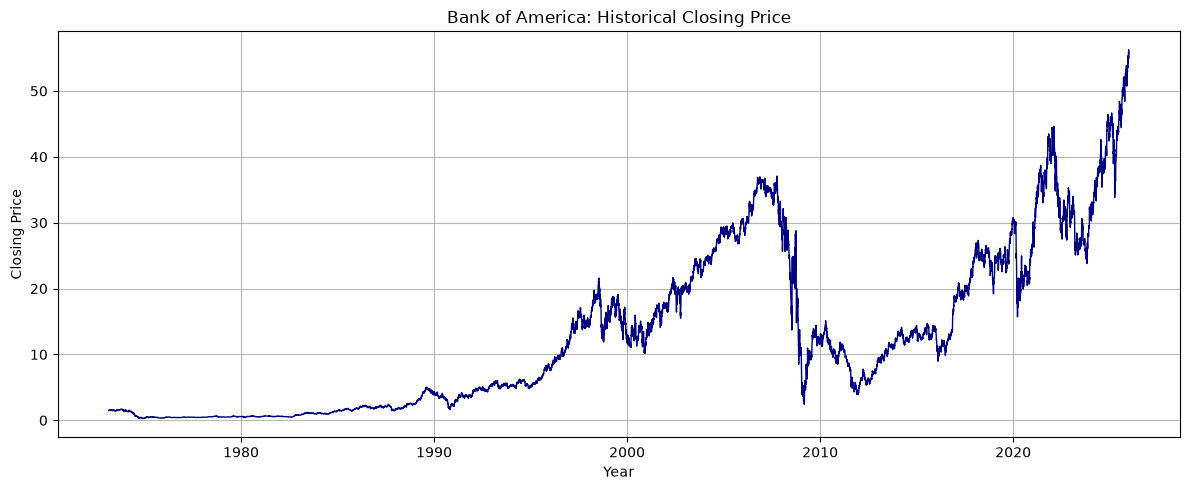

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Close"], color="navy", linewidth=1)

plt.title("Bank of America: Historical Closing Price")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.grid(alpha=0.9)
plt.tight_layout()
plt.savefig("01_Closing_Price_Trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
highest= df.loc[df["Close"].idxmax(), ["Date", "Close"]]
lowest= df.loc[df["Close"].idxmin(), ["Date", "Close"]]

print("Highest Closing Price:")
print(highest)
print("\nLowest Closing Price:")
print(lowest)

Highest Closing Price:
Date     2025-12-24 00:00:00-05:00
Close                        56.25
Name: 13324, dtype: object

Lowest Closing Price:
Date     1974-12-20 00:00:00-05:00
Close                     0.269949
Name: 464, dtype: object


In [43]:
df["Year"] = df["Date"].dt.year

yearly_avg = df.groupby("Year") ["Close"].mean()

yearly_avg.tail(10).round(2)

Year
2016    12.49
2017    20.31
2018    24.79
2019    25.20
2020    22.98
2021    36.14
2022    33.93
2023    28.15
2024    37.87
2025    46.61
Name: Close, dtype: float64

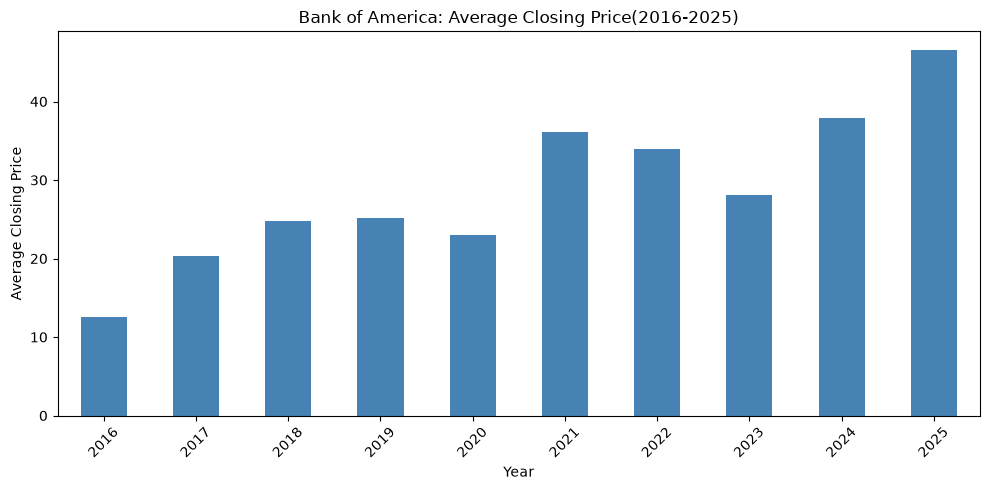

In [69]:
yearly_avg.tail(10).plot(
    kind= "bar",
    figsize=(10, 5),
    color= "steelblue"
)

plt.title("Bank of America: Average Closing Price(2016-2025)")
plt.xlabel("Year")
plt.ylabel("Average Closing Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("02_Annual_Average_Close.png", dpi=300, bbox_inches="tight")
plt.show()

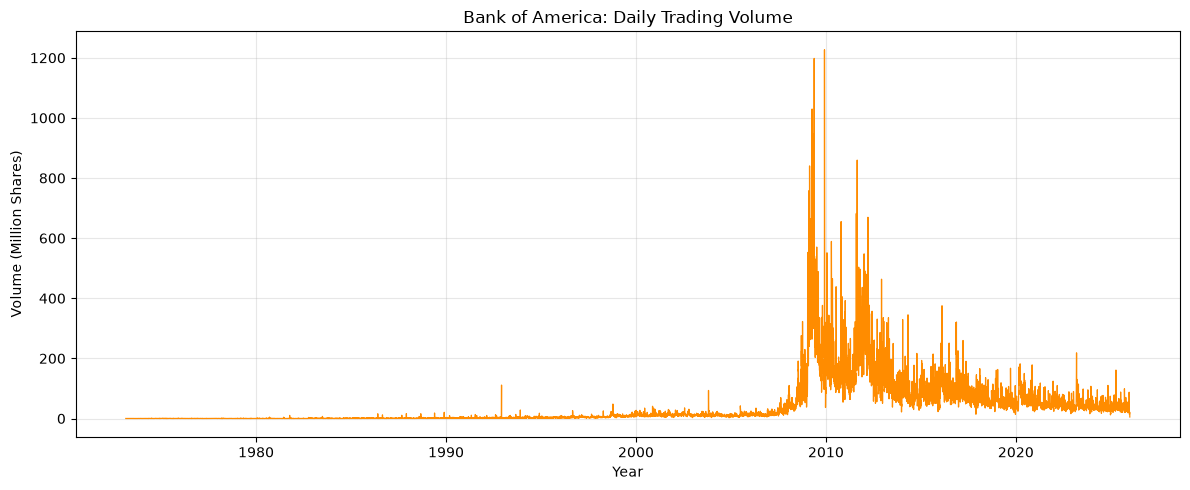

In [70]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Volume"] / 1_000_000, color="darkorange", linewidth= 0.9)

plt.title("Bank of America: Daily Trading Volume")
plt.xlabel("Year")
plt.ylabel("Volume (Million Shares)")
plt.grid(alpha= 0.3)
plt.tight_layout()
plt.savefig("03_Daily_Trading_Volume.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
top_volume = df.nlargest(5, "Volume")

top_volume[["Date", "Close", "Volume"]]

,Date,Close,Volume
9286,2009-12-04 00:00:00-05:00,12.626793,1226791300
9148,2009-05-20 00:00:00-04:00,8.892844,1197984500
9120,2009-04-09 00:00:00-04:00,7.391355,1029694600
9139,2009-05-07 00:00:00-04:00,10.456253,946806700
9138,2009-05-06 00:00:00-04:00,9.821601,924590100


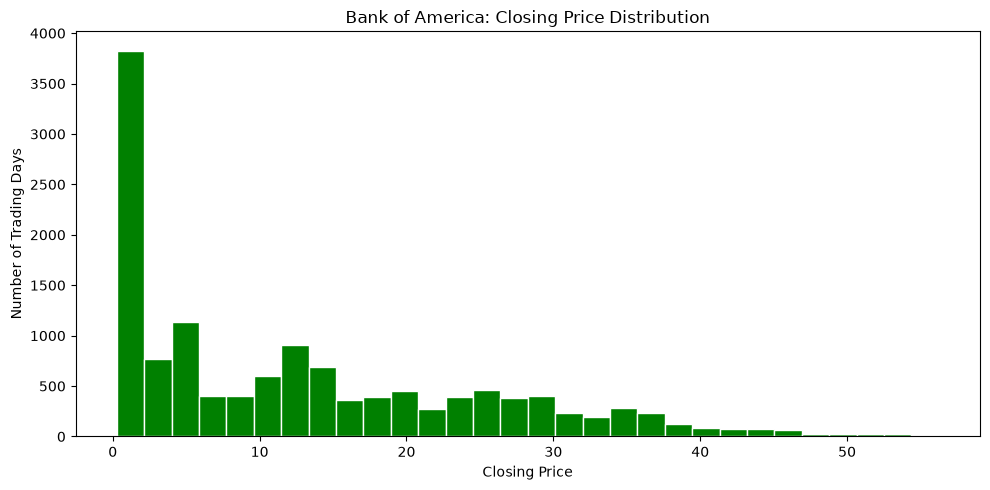

In [71]:
plt.figure(figsize=(10,5))
plt.hist(df["Close"], bins=30, color= "green", edgecolor= "white")

plt.title("Bank of America: Closing Price Distribution")
plt.xlabel("Closing Price")
plt.ylabel("Number of Trading Days")
plt.tight_layout()
plt.savefig("04_Closing_Price_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

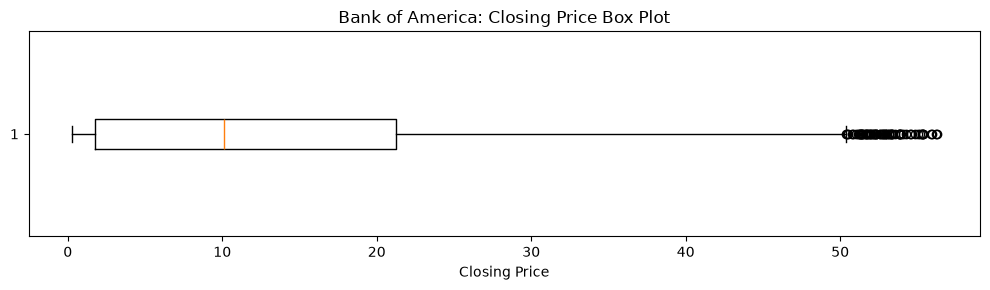

In [72]:
plt.figure(figsize=(10,3))
plt.boxplot(df["Close"], orientation= "horizontal")

plt.title("Bank of America: Closing Price Box Plot")
plt.xlabel("Closing Price")
plt.tight_layout()
plt.savefig("05_Closing_Price_Box_Plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [64]:
q1 = df["Close"].quantile(0.25)
q3 = df["Close"].quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outliers = df[
    (df["Close"] < lower_limit) |
    (df["Close"] > upper_limit)
]

print("Lower limit:", round(lower_limit, 2))
print("Upper limit:", round(upper_limit, 2))
print("Outlier rows:", len(outliers))

Lower limit: -27.4
Upper limit: 50.38
Outlier rows: 66


In [65]:
print("Outlier rows by year:")
print(outliers["Date"].dt.year.value_counts().sort_index())

Outlier rows by year:
Date
2025    66
Name: count, dtype: int64


In [66]:
df["Close_Outlier_Flag"] = (
    (df["Close"] < lower_limit) |
    (df["Close"] > upper_limit)
)

print("Flagged rows:", df["Close_Outlier_Flag"].sum())
print("Total rows retained:", len(df))

Flagged rows: 66
Total rows retained: 13329


In [67]:
df.to_csv("Bank_of_America_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Key Findings and Cleaning Decisions

- The dataset contains 13,329 records from 1973 to 2025.
- No missing values, duplicate rows, or duplicate dates were found.
- Dates were converted to datetime and sorted chronologically.
- Six zero-volume records were flagged and retained because their
  cause could not be confirmed.
- Mean closing price was 12.86 and median was 10.10.
  The full-history closing-price distribution was right-skewed.
- The highest closing price was 56.25 on 24 December 2025.
- All five highest-volume trading days occurred in 2009.
- The IQR method flagged 66 high closing prices, all from 2025.
  These were retained because a statistical outlier is not
  automatically a data error.
- All original rows were retained, and the prepared dataset was
  exported as Bank_of_America_Cleaned.csv.

## Interpretation Note

These findings describe the supplied historical dataset.
Annual average prices are not annual returns, and the full-history
price distribution does not represent future price probabilities.